In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import seaborn as sns
from sklearn.impute import SimpleImputer
import numpy as np

In [ ]:
from pathlib import Path

DATA_DIR = Path("NHANES DATA")
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Can't find the data folder at {DATA_DIR.resolve()}. "
        "Make sure 'NHANES DATA' is in the same folder as this notebook."
    )

ALL_YEARS = ["2013-2014", "2015-2016", "2017-2020", "2021-2023"]

def data_files(name, years=ALL_YEARS):
    """Build the list of .xpt paths for one dataset, e.g. data_files("glucose")."""
    return [DATA_DIR / f"{name}_{year}.xpt" for year in years]

gluocse_file_path = data_files("glucose")
smoking_file_path = data_files("smoking")
diet1_file_path = data_files("diet1")
diet2_file_path = data_files("diet2")
demographics_file_path = data_files("demographic")
physical_file_path = data_files("physical")
weight_file_path = data_files("weight")
sleep_file_path = data_files("sleep", ALL_YEARS[1:])  # 2013-2014 excluded bc titled SLD010H
alcohol_file_path = data_files("alcohol")
body_file_path = data_files("body")
medical_file_path = data_files("medical")
insurance_file_path = data_files("insurance")
blood_file_path = data_files("bloodpressure")

In [3]:
glucose_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'LBDGLUSI']] for file in gluocse_file_path]
glucose_df = pd.concat(glucose_dataframes, ignore_index=True)

smoking_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'SMQ020']] for file in smoking_file_path]
smoking_df = pd.concat(smoking_dataframes, ignore_index=True)

diet1_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'DR1TKCAL', 'DR1TPROT', 'DR1TCARB','DR1TSUGR', 'DR1TFIBE','DR1TTFAT', 'DR1TCHOL']] for file in diet1_file_path]
diet1_df = pd.concat(diet1_dataframes, ignore_index=True)

diet2_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'DR2TKCAL', 'DR2TPROT', 'DR2TCARB','DR2TSUGR', 'DR2TFIBE','DR2TTFAT', 'DR2TCHOL']] for file in diet2_file_path]
diet2_df = pd.concat(diet2_dataframes, ignore_index=True)

demographics_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'RIAGENDR', 'RIDAGEYR','RIDRETH1', 'INDFMPIR']] for file in demographics_file_path]
demographics_df = pd.concat(demographics_dataframes, ignore_index=True)

physical_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'PAD680']] for file in physical_file_path]
physical_df = pd.concat(physical_dataframes, ignore_index=True)

weight_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'WHD010', 'WHD020']] for file in weight_file_path]
weight_df = pd.concat(weight_dataframes, ignore_index=True)

sleep_dataframes = []

for file in sleep_file_path:
    df = pd.read_sas(file, format='xport')
    if 'SLD012' in df.columns:
        sleep_dataframes.append(df[['SEQN', 'SLD012']])
    elif 'SLD010H' in df.columns:
        sleep_dataframes.append(df[['SEQN', 'SLD010H']].rename(columns={'SLD010H': 'SLD012'}))  # Rename for consistency

sleep_df = pd.concat(sleep_dataframes, ignore_index=True)

alcohol_dataframes = []

for file in alcohol_file_path:
    df = pd.read_sas(file, format='xport')
    if 'ALQ111' in df.columns:
        alcohol_dataframes.append(df[['SEQN', 'ALQ111']])
    elif 'ALQ110' in df.columns:
        alcohol_dataframes.append(df[['SEQN', 'ALQ110']].rename(columns={'ALQ110': 'ALQ111'}))  # Rename for consistency

alcohol_df = pd.concat(sleep_dataframes, ignore_index=True)


body_dataframes = [pd.read_sas(file, format='xport')[['SEQN', 'BMXWAIST']] for file in body_file_path]
body_df = pd.concat(body_dataframes, ignore_index=True)

medical_dataframes = []

for file in medical_file_path:
    df = pd.read_sas(file, format='xport')
    
    if 'MCQ366B' in df.columns:
        medical_dataframes.append(df[['SEQN', 'MCQ300C', 'MCQ080', 'MCQ366A', 'MCQ366B', 'MCQ371A', 'MCQ371B', 'MCQ160C', 'MCQ160E', 'MCQ160B']])
    
    elif 'MCQ365B' in df.columns:
        renamed_df = df[['SEQN', 'MCQ300C', 'MCQ080', 'MCQ365A', 'MCQ365B', 'MCQ370A', 'MCQ370B', 'MCQ160C', 'MCQ160E', 'MCQ160B']].rename(
            columns={
                'MCQ365A': 'MCQ366A',
                'MCQ365B': 'MCQ366B',
                'MCQ370A': 'MCQ371A',
                'MCQ370B': 'MCQ371B'
            }
        )
        medical_dataframes.append(renamed_df)
medical_df = pd.concat(medical_dataframes, ignore_index=True)


insurance_dataframes = [pd.read_sas(file, format="xport")[['SEQN', 'HIQ011']] for file in insurance_file_path]
insurance_df = pd.concat(insurance_dataframes, ignore_index=True)

blood_dataframes = []

for file in blood_file_path:
    df = pd.read_sas(file, format='xport')
    
    if 'BPQ050A' in df.columns:
        blood_dataframes.append(df[['SEQN', 'BPQ020', 'BPQ080', 'BPQ090D']])
    
    elif 'BPQ150' in df.columns:
        renamed_df = df[['SEQN', 'BPQ020', 'BPQ080', 'BPQ101D']].rename(
            columns={
                'BPQ101D': 'BPQ090D'
            }
        )
        blood_dataframes.append(renamed_df)
blood_df = pd.concat(blood_dataframes, ignore_index=True)


In [4]:
glucose_df.columns = ['ID', 'glucose']
smoking_df.columns=['ID', 'smoking']
diet1_df.columns=['ID', 'calories1', 'protein1','carbs1','sugar1','fiber1','fat1', 'cholesterol1']
diet2_df.columns=['ID', 'calories2', 'protein2','carbs2','sugar2','fiber2','fat2', 'cholesterol2']
demographics_df.columns = ['ID', 'gender', 'age', 'ethnicity', 'household income']
physical_df.columns=['ID', 'sedentary']
weight_df.columns=['ID', 'height', 'weight']
sleep_df.columns=['ID','hours of sleep']
alcohol_df.columns=['ID', 'ever had alcohol']

medical_df.columns=['ID','family history', 'doctor overweight', 'doctor lose weight', 'doctor exercise', 'losing weight', 'increasing exercise', 'heart disease', 'heart attack', 'heart failure']
insurance_df.columns=['ID', 'health insurance']
blood_df.columns=['ID', 'high blood pressure', 'high cholesterol', 'prescription for cholesterol']
body_df.columns=['ID', 'waist']


In [5]:
#drop missing glucose values
glucose_df=glucose_df.dropna()

#diagnose diabetes from 2 hour fasting period according to WHO guidelines
glucose_df['diagnosis'] = glucose_df['glucose'].apply(lambda x: 1 if x > 7.0 else 0)
glucose_df.drop(columns=['glucose'], inplace=True)

In [6]:
#merge all dataframes into combined dataframe
combined_df = glucose_df.merge(smoking_df, on='ID', how='left')\
                         .merge(diet1_df, on='ID', how='left')\
                         .merge(diet2_df, on='ID', how='left')\
                         .merge(demographics_df, on='ID', how='left')\
                         .merge(physical_df, on='ID', how='left')\
                         .merge(weight_df, on='ID', how='left')\
                         .merge(sleep_df, on='ID', how='left')\
                         .merge(alcohol_df, on='ID', how='left')\
                         .merge(medical_df, on='ID', how='left')\
                         .merge(insurance_df, on='ID', how='left')\
                         .merge(blood_df, on='ID', how='left')\
                         .merge(body_df, on='ID', how="left")
combined_df.drop(columns=['ID'], inplace=True)

In [7]:
#create new column for BMI
combined_df['BMI'] = (703*combined_df['weight']) / (combined_df['height'] ** 2)

# Drop the original height and weight columns
combined_df.drop(columns=['height', 'weight'], inplace=True)

In [8]:
#create a new column of average of two days of nutrient tracking
nutrient_pairs = [
    ('calories1', 'calories2'),
    ('protein1', 'protein2'),
    ('fiber1', 'fiber2'),
    ('carbs1', 'carbs2'),
    ('fat1', 'fat2'),
    ('sugar1', 'sugar2'),
    ('cholesterol1', 'cholesterol2')
]

# Create new averaged column
for new_col, (col1, col2) in zip(['avg_' + pair[0] for pair in nutrient_pairs], nutrient_pairs):
    if col1 in combined_df.columns and col2 in combined_df.columns:
        combined_df[new_col] = combined_df[[col1, col2]].mean(axis=1)
    else:
        print(f"Warning: Columns {col1} or {col2} not found - skipping {new_col}")

# Now delete the old columns
cols_to_drop = []
for col1, col2 in nutrient_pairs:
    if col1 in combined_df.columns:
        cols_to_drop.append(col1)
    if col2 in combined_df.columns:
        cols_to_drop.append(col2)

combined_df = combined_df.drop(columns=cols_to_drop)

# Verify the new columns
print(combined_df.to_string())

       diagnosis  smoking  gender   age  ethnicity  household income     sedentary  hours of sleep  ever had alcohol  family history  doctor overweight  doctor lose weight  doctor exercise  losing weight  increasing exercise  heart disease  heart attack  heart failure  health insurance  high blood pressure  high cholesterol  prescription for cholesterol  waist          BMI  avg_calories1  avg_protein1    avg_fiber1    avg_carbs1      avg_fat1    avg_sugar1  avg_cholesterol1
0              1      1.0     1.0  72.0        3.0      4.510000e+00  3.000000e+02             NaN               NaN             2.0                2.0                 2.0              2.0            2.0                  2.0            2.0           2.0            2.0               1.0                  1.0               1.0                           1.0  109.2    27.976531   1.845000e+03  6.256000e+01  1.035000e+01  2.554300e+02  6.537000e+01  1.171300e+02      7.200000e+01
1              0      2.0     2.0  73.0   

In [9]:
print(combined_df.isnull().sum())

diagnosis                          0
smoking                         1761
gender                             0
age                                0
ethnicity                          0
household income                1624
sedentary                        962
hours of sleep                  4110
ever had alcohol                4110
family history                  5530
doctor overweight               4616
doctor lose weight              4616
doctor exercise                 4616
losing weight                   4616
increasing exercise             4616
heart disease                   5530
heart attack                    5530
heart failure                   5530
health insurance                   0
high blood pressure             1170
high cholesterol                1170
prescription for cholesterol    3767
waist                            660
BMI                             1219
avg_calories1                   1624
avg_protein1                    1624
avg_fiber1                      1624
a

/var/folders/2x/34fb7xcx7m5cyr_r8ckmc_2h0000gn/T/ipykernel_43994/4122293326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diagnosis', y='count', data=diagnosis_counts, palette='Set2')


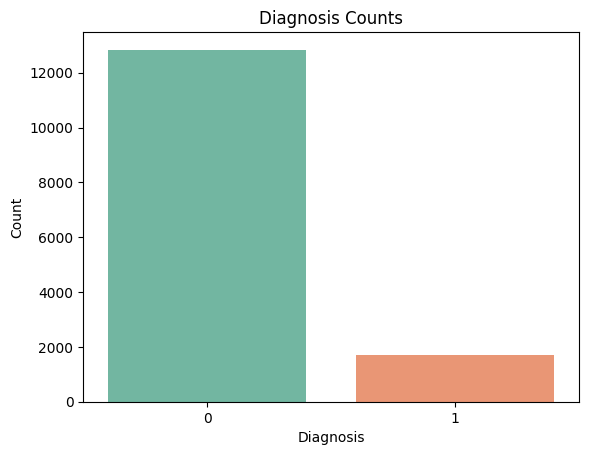

In [10]:
# Count the occurrences of each diagnosis
diagnosis_counts = combined_df['diagnosis'].value_counts().reset_index()
diagnosis_counts.columns = ['diagnosis', 'count']

# Create the bar plot with a color palette
sns.barplot(x='diagnosis', y='count', data=diagnosis_counts, palette='Set2')

# Add title and labels
plt.title('Diagnosis Counts')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Show the plot
plt.show()

/var/folders/2x/34fb7xcx7m5cyr_r8ckmc_2h0000gn/T/ipykernel_43994/2568318392.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='column', x='missing_count', data=missing_counts, palette='Set2')


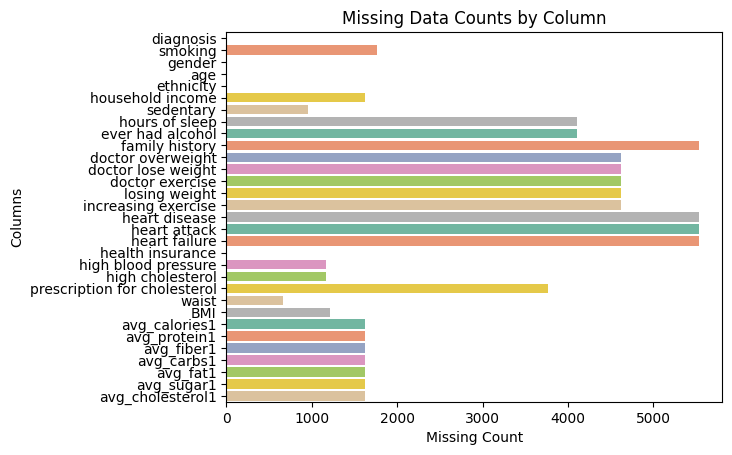

In [11]:
missing_counts = combined_df.isnull().sum().reset_index()
missing_counts.columns = ['column', 'missing_count']

# Create the horizontal bar plot with a color palette
sns.barplot(y='column', x='missing_count', data=missing_counts, palette='Set2')

# Add title and labels
plt.title('Missing Data Counts by Column')
plt.xlabel('Missing Count')
plt.ylabel('Columns')

# Show the plot
plt.show()

In [12]:
unique, counts = np.unique(combined_df['diagnosis'], return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(12839), np.int64(1): np.int64(1721)}


In [13]:
cat_columns = ['gender', 'age','ethnicity', 'ever had alcohol', 'smoking', 'family history', 'doctor overweight', 'doctor lose weight', 'doctor exercise', 'losing weight', 'increasing exercise', 'heart disease', 'heart attack', 'heart failure','health insurance', 'high blood pressure', 'high cholesterol', 'prescription for cholesterol']
num_columns = [col for col in combined_df.columns if col not in cat_columns + ['diagnosis']]

#impute the data using average
# For numerical features
num_imputer = SimpleImputer(strategy='mean')
combined_df[num_columns] = num_imputer.fit_transform(combined_df[num_columns])

# For categorical features
cat_imputer = SimpleImputer(strategy='most_frequent')
combined_df[cat_columns] = cat_imputer.fit_transform(combined_df[cat_columns])

# Normalize the numerical features
scaler = StandardScaler()
combined_df[num_columns] = scaler.fit_transform(combined_df[num_columns])

# Encode categorical features
label_encoders = {}
for col in cat_columns:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col])
    label_encoders[col] = le

# Recalculate category sizes
category_sizes = [combined_df[col].nunique() for col in cat_columns]

In [14]:
# Data and target
X = combined_df[cat_columns + num_columns].values
y = combined_df['diagnosis'].values

# Initial train-test split (no leakage)
X_train, X_test, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:

# SMOTE-NC on training data only
cat_indices = list(range(len(cat_columns)))

smote_nc = SMOTENC(categorical_features=cat_indices, sampling_strategy=1, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train_np)

# Convert to tensors
X_cat_train = torch.tensor(X_train_res[:, :len(cat_columns)], dtype=torch.long)
X_num_train = torch.tensor(X_train_res[:, len(cat_columns):], dtype=torch.float32)
y_train = torch.tensor(y_train_res, dtype=torch.float32).unsqueeze(1)

X_cat_test = torch.tensor(X_test[:, :len(cat_columns)], dtype=torch.long)
X_num_test = torch.tensor(X_test[:, len(cat_columns):], dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32).unsqueeze(1)

In [16]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.float32(0.0): np.int64(10271), np.float32(1.0): np.int64(10271)}


In [17]:
# TabTransformer definition
class TabTransformer(nn.Module):
    def __init__(self, categories, num_continuous, dim=32, depth=2, heads=4, dropout=0.2): #changed dimension size 32-16
        super().__init__()
        self.cat_embeds = nn.ModuleList([nn.Embedding(cat_size, dim) for cat_size in categories])
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=dim, nhead=heads, dropout=dropout, batch_first=True),
            num_layers=depth
        )
        self.cont_bn = nn.BatchNorm1d(num_continuous) if num_continuous > 0 else None
        self.mlp = nn.Sequential(
            nn.Linear(dim * len(categories) + num_continuous, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x_cat, x_cont):
        cat_embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeds)]
        x_cat = torch.stack(cat_embeds, dim=1)
        x_cat = self.transformer(x_cat).flatten(1)
        if x_cont is not None and self.cont_bn:
            x_cont = self.cont_bn(x_cont)
        x = torch.cat([x_cat, x_cont], dim=1) if x_cont is not None else x_cat
        return self.mlp(x)


# Instantiate model
model = TabTransformer(categories=category_sizes, num_continuous=len(num_columns))

In [18]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [19]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import LambdaLR

# Set batch size
batch_size = 256

# Create datasets and dataloaders
train_dataset = TensorDataset(X_cat_train, X_num_train, y_train)
test_dataset = TensorDataset(X_cat_test, X_num_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=batch_size)

# Instantiate model
model = TabTransformer(categories=category_sizes, num_continuous=len(num_columns))
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate warmup scheduler
warmup_steps = 20  # you can increase this for a smoother warmup
def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step + 1) / warmup_steps  # linearly increase lr
    return 1.0  # constant lr afterwards

scheduler = LambdaLR(optimizer, lr_lambda)

train_losses = []
val_losses = []

early_stopper = EarlyStopping(patience=5, min_delta=0.001)

# Training loop
for epoch in range(40):
    model.train()
    epoch_loss = 0
    for x_cat_batch, x_num_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(x_cat_batch, x_num_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f"Epoch {epoch+1:02} | Train Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in val_loader:
            val_outputs = model(x_cat_batch, x_num_batch)
            loss = criterion(val_outputs, y_batch)
            val_loss += loss.item()
    
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"| Validation Loss: {avg_val_loss:.4f}")
    early_stopper(avg_val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered!")
        break

Epoch 01 | Train Loss: 0.4973
| Validation Loss: 0.4454
Epoch 02 | Train Loss: 0.4412
| Validation Loss: 0.5319
Epoch 03 | Train Loss: 0.4169
| Validation Loss: 0.4815
Epoch 04 | Train Loss: 0.4004
| Validation Loss: 0.4760
Epoch 05 | Train Loss: 0.3950
| Validation Loss: 0.4503
Epoch 06 | Train Loss: 0.3842
| Validation Loss: 0.4462
Early stopping triggered!


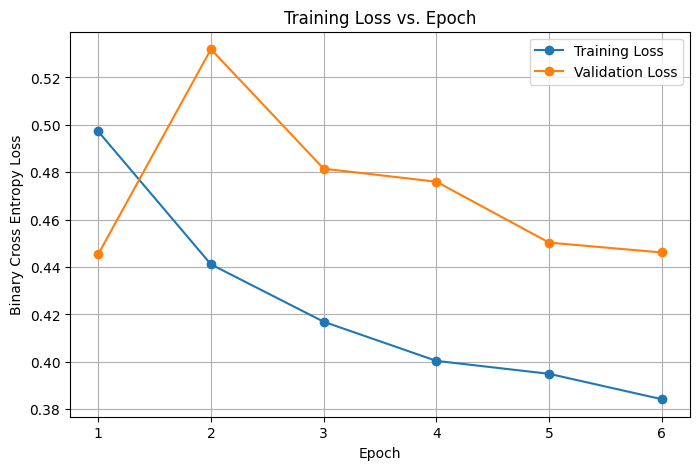

In [20]:
plt.figure(figsize=(8, 5))

# Plot training losses
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss')
# Plot validation losses
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label='Validation Loss')
# Add title and labels
plt.title("Training Loss vs. Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
# Add a legend
plt.legend()
# Show the plot
plt.show()


In [58]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import torch

# Evaluate model
model.eval()
with torch.no_grad():
    logits = model(X_cat_test, X_num_test)
    probs = torch.sigmoid(logits).squeeze()
    preds = (probs > 0.67).int()

# Convert to NumPy
y_true = y_test.squeeze().numpy()
y_pred = preds.numpy()
y_prob = probs.numpy()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall_weighted = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Confusion matrix and specificity
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Specificity calculation
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Avoid division by zero

# Non-weighted sensitivity calculation
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Avoid division by zero

# Print metrics
print(f"Weighted Accuracy:            {accuracy:.4f}")
print(f"Weighted Precision:           {precision:.4f}")
print(f"Weighted Recall (Sensitivity): {recall_weighted:.4f}")
print(f"Non-weighted Sensitivity:     {sensitivity:.4f}")
print(f"Weighted F1 Score:            {f1:.4f}")
print(f"Specificity:                  {specificity:.4f}")


Weighted Accuracy:            0.8362
Weighted Precision:           0.8530
Weighted Recall (Sensitivity): 0.8362
Non-weighted Sensitivity:     0.4302
Weighted F1 Score:            0.8438
Specificity:                  0.8906


In [48]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.89      0.91      2568
         1.0       0.34      0.43      0.38       344

    accuracy                           0.84      2912
   macro avg       0.63      0.66      0.64      2912
weighted avg       0.85      0.84      0.84      2912



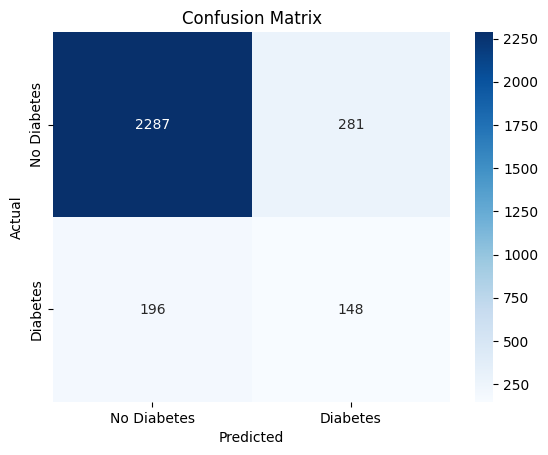

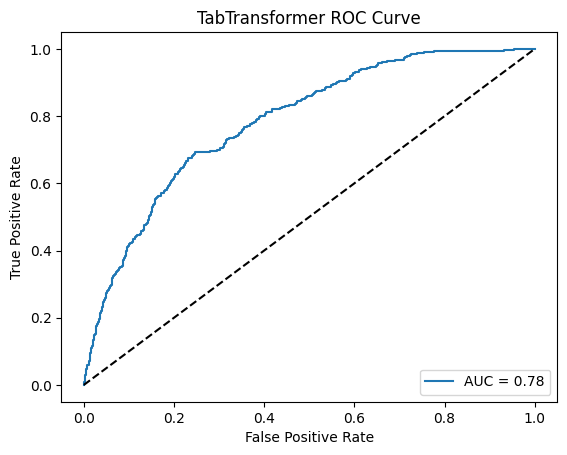

In [57]:
# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["No Diabetes", "Diabetes"], 
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TabTransformer ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [52]:
# Generate predictions from the trained TabTransformer
model.eval()  # Switch the model to evaluation mode
with torch.no_grad():
    train_preds = model(X_cat_train, X_num_train).squeeze().numpy()
train_preds_binary = (train_preds >= 0.67).astype(int)


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Train surrogate random forest model
surrogate_model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
surrogate_model_rf.fit(X_train_res, train_preds_binary) 

surrogate_preds_rf = surrogate_model_rf.predict(X_test)

# Evaluate the surrogate model's performance
print(f"Accuracy of the surrogate model (Random Forest): {accuracy_score(y_test_np, surrogate_preds_rf):.4f}")
print("Classification Report:\n", classification_report(y_test_np, surrogate_preds_rf))

Accuracy of the surrogate model (Random Forest): 0.8372
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.89      0.91      2568
           1       0.35      0.43      0.38       344

    accuracy                           0.84      2912
   macro avg       0.63      0.66      0.65      2912
weighted avg       0.85      0.84      0.84      2912



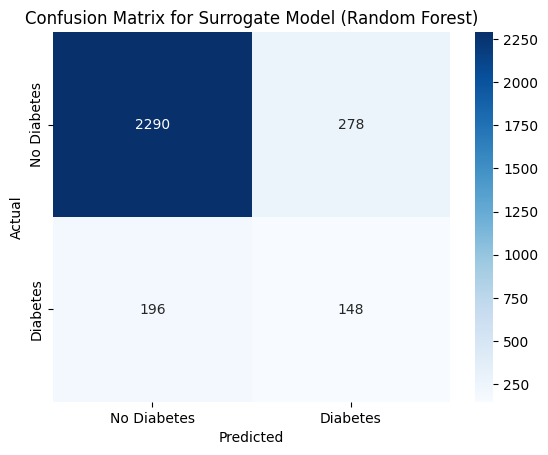

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2568
           1       0.35      0.43      0.38       344

    accuracy                           0.84      2912
   macro avg       0.63      0.66      0.65      2912
weighted avg       0.85      0.84      0.84      2912



In [54]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test_np, surrogate_preds_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Surrogate Model (Random Forest)')
plt.show()

# Classification report
print(classification_report(y_test_np, surrogate_preds_rf))


In [55]:
from sklearn.metrics import precision_recall_curve

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

# Compute F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# Find the threshold with the best F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold based on F1 score: {best_threshold:.2f}")


Best threshold based on F1 score: 0.55


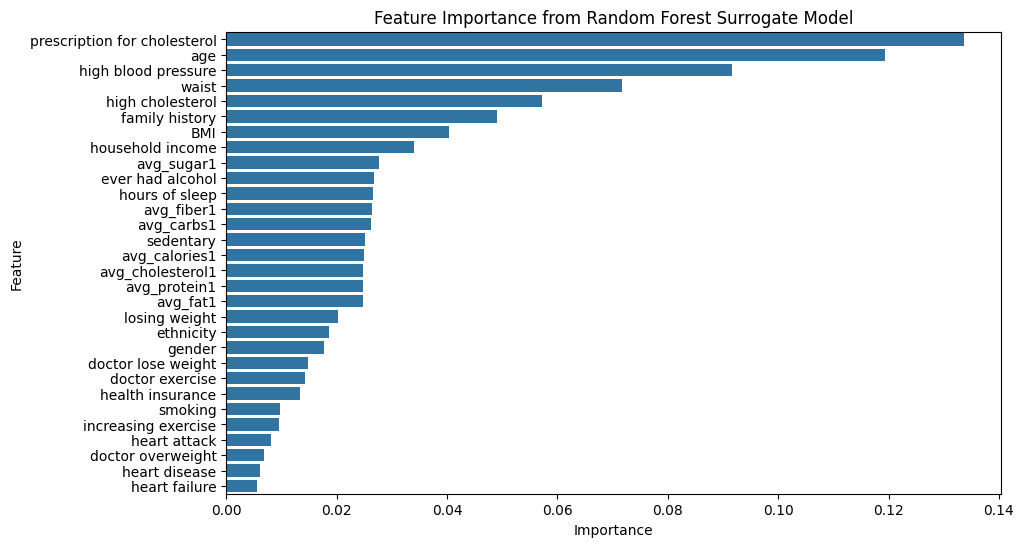

In [56]:
# Get feature importances from the surrogate model (Random Forest)
importances = surrogate_model_rf.feature_importances_

# Visualize feature importances
features = combined_df[cat_columns + num_columns].columns
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Surrogate Model')
plt.show()